#Nama: Ghoffar Abdul Ja'far
#NIM: 2341720035
#Kelas: TI 3H

## MODUL 5 - Histogram, Histogram Equalization, Dithering

### D. PERCOBAAN PRAKTIKUM

#### D-1 PERCOBAAN HISTOGRAM

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

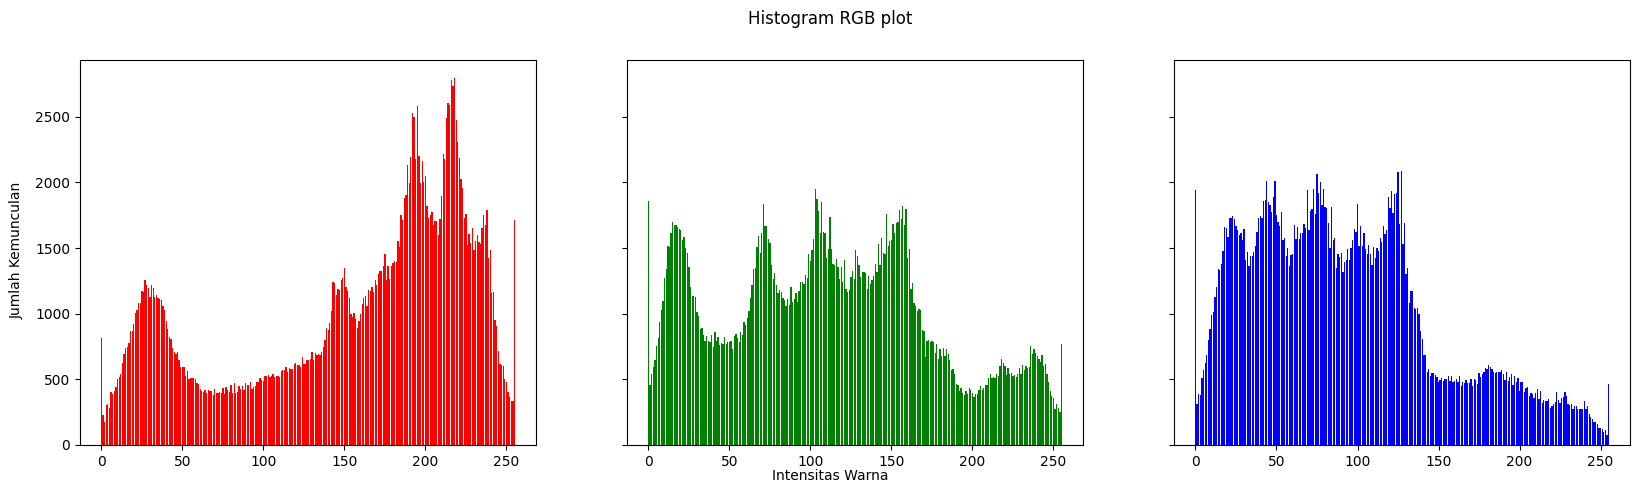

In [4]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np. shape (img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red [img [y] [x] [0]] += 1
    green [img [y] [x] [1]] += 1
    blue [img [y] [x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

#### PERTANYAAN PRAKTIKUM D1


1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?


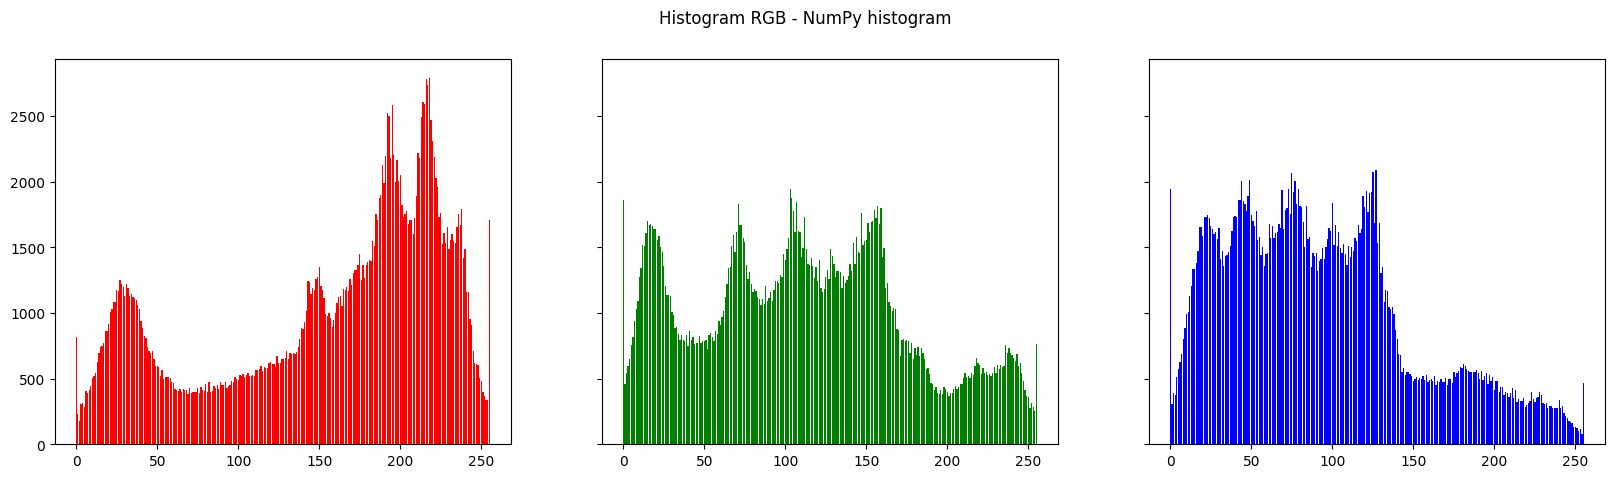

In [5]:
# Pisahkan channel
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

# Histogram dengan numpy
hist_R, _ = np.histogram(R, bins=256, range=(0, 256))
hist_G, _ = np.histogram(G, bins=256, range=(0, 256))
hist_B, _ = np.histogram(B, bins=256, range=(0, 256))

# Plot
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB - NumPy histogram')
axs[0].bar(names, hist_R, color='red')
axs[1].bar(names, hist_G, color='green')
axs[2].bar(names, hist_B, color='blue')
plt.show()

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg. Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah

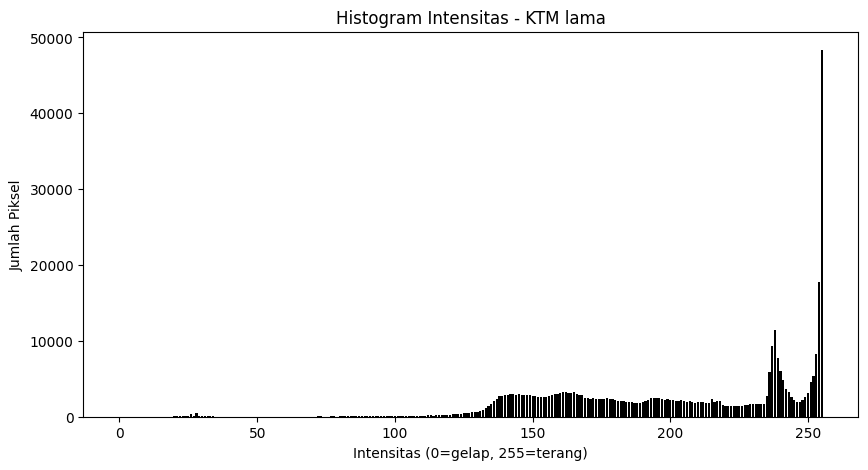

In [6]:
# Baca gambar KTM
img = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM lama.jpg')

# Ubah ke grayscale (analisis intensitas lebih mudah di grayscale)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Histogram intensitas grayscale
hist, bins = np.histogram(gray, bins=256, range=(0, 256))

# Plot
plt.figure(figsize=(10,5))
plt.bar(np.arange(256), hist, color='black')
plt.title('Histogram Intensitas - KTM lama')
plt.xlabel('Intensitas (0=gelap, 255=terang)')
plt.ylabel('Jumlah Piksel')
plt.show()

#### D-2 PERCOBAAN HISTOGRAM EQUALIZATION

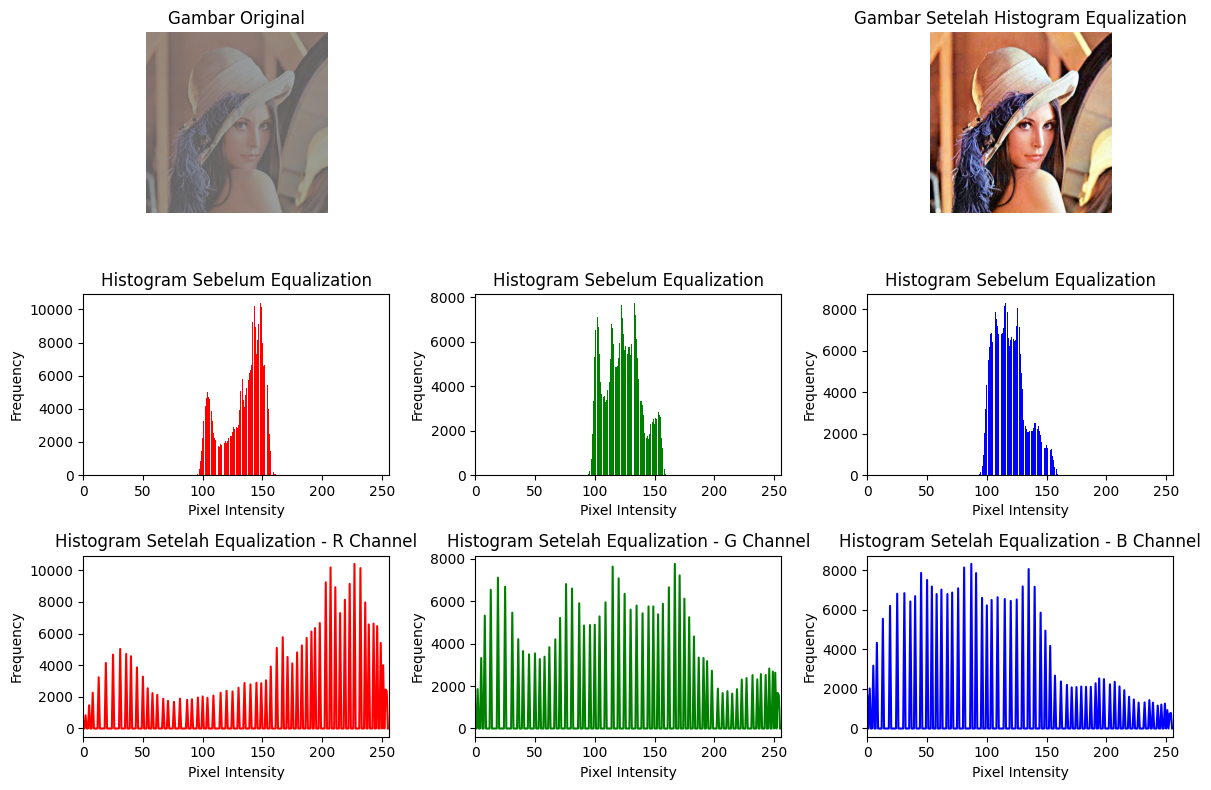

In [7]:
# Step 1: Input image (lena_lc.jpg)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Step 2: Menghitung jumlah kemunculan setiap pixel warna (frekuensi)
hist, bins = np.histogram(img.flatten(), 256, [0, 256])

# Step 3: Menghitung penjumlahan kumulatif dari frekuensi
cdf = hist.cumsum()

# Step 4: Normalisasi, membagi dengan jumlah total pixel
cdf_normalized = cdf * hist.max() / cdf.max()

# Step 5: Implementasi rumus k0, Normalisasi CDF
cdf_m = np.ma.masked_equal(cdf, 0)  # Mengabaikan nilai 0
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())  # Rumus Normalisasi
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')  # Mengisi kembali nilai yang diabaikan

# Step 6: Menerapkan CDF hasil equalization pada gambar
img_equalized = cdf_final[img]

plt.figure(figsize=(12, 8))

plt.subplot(3, 3, 1)
plt.imshow(img)
plt.title('Gambar Original')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(img_equalized)
plt.title('Gambar Setelah Histogram Equalization')
plt.axis('off')

colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    plt.subplot(3, 3, 3 + i + 1)
    hist = cv.calcHist([img], [i], None, [256], [0, 256])
    plt.bar(range(256), hist.flatten(), color=color)
    plt.title('Histogram Sebelum Equalization')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

for i, color in enumerate(colors):
    plt.subplot(3, 3, 6 + i + 1)  # 3 rows, 2 columns
    hist_eq = cv.calcHist([img_equalized], [i], None, [256], [0, 256])
    plt.plot(hist_eq, color=color)
    plt.title(f'Histogram Setelah Equalization - {color.upper()} Channel')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini.

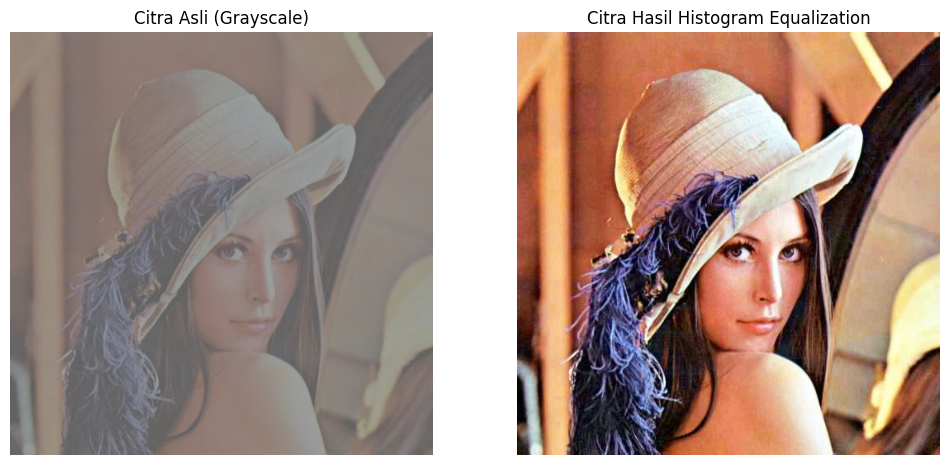

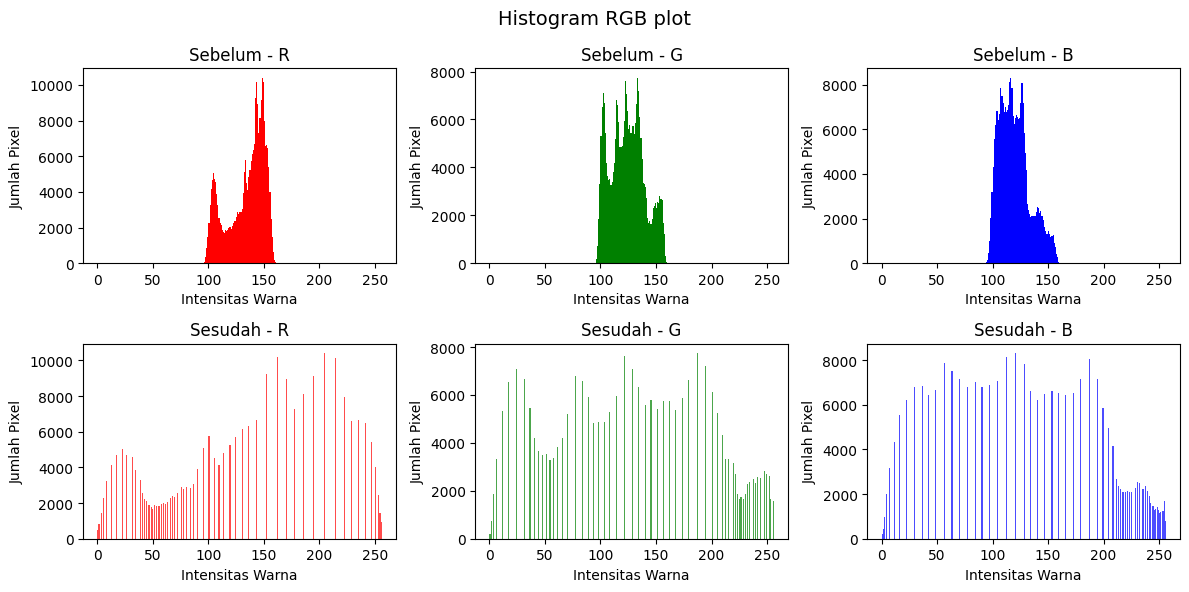

In [10]:
# Start / Input Image
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Hitung Frekuensi (histogram)
hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])


# Hitung Kumulatif Frekuensi
cdf = hist.cumsum()

# Normalisasi CDF (bagi dengan jumlah pixel dan skala ke 0-255)
cdf_normalized = cdf * 255 / cdf[-1]

# Implementasi rumus transformasi equalization
img_eq = np.interp(img.flatten(), bins[:-1], cdf_normalized)
img_eq = img_eq.reshape(img.shape).astype('uint8')

# Visualisasi
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Citra Asli (Grayscale)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Citra Hasil Histogram Equalization")
plt.axis("off")
plt.show()

# Pisah channel RGB
R, G, B = cv.split(img)

# Equalize per channel
R_eq = cv.equalizeHist(R)
G_eq = cv.equalizeHist(G)
B_eq = cv.equalizeHist(B)

# Gabungkan kembali
channels_orig = [R, G, B]
channels_eq = [R_eq, G_eq, B_eq]

plt.figure(figsize=(12,6))
plt.suptitle("Histogram RGB plot", fontsize=14)

for i, col in enumerate(colors):
    # Sebelum equalization (baris atas)
    plt.subplot(2,3,i+1)
    plt.hist(channels_orig[i].ravel(), bins=256, range=(0,256), color=col)
    plt.title(f"Sebelum - {col.upper()}")
    plt.xlabel("Intensitas Warna")
    plt.ylabel("Jumlah Pixel")

    # Sesudah equalization (baris bawah)
    plt.subplot(2,3,i+4)
    plt.hist(channels_eq[i].ravel(), bins=256, range=(0,256), color=col, alpha=0.7)
    plt.title(f"Sesudah - {col.upper()}")
    plt.xlabel("Intensitas Warna")
    plt.ylabel("Jumlah Pixel")

plt.tight_layout()
plt.show()

#### PERTANYAAN PRAKTIKUM D2




1. Perbandingan Citra Lena
* a. Gunakan hasil histogram equalization pada citra lena.jpg.
* b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.
* c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas
visual citra? Apakah ada detail baru yang muncul setelah equalization?

In [11]:
# PSNR
def compute_psnr(img, img_eq):
    mse = np.mean((img.astype(np.float64) - img_eq.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    psnr = 10 * np.log10((PIXEL_MAX ** 2) / mse)
    return psnr

psnr_rgb_equalized = compute_psnr(img, img_eq)

print("PSNR (original vs equalize per-channel RGB):", psnr_rgb_equalized)

PSNR (original vs equalize per-channel RGB): 12.98588185586433


2. Gunakan Citra KTM Lama.jpg
* a. Terapkan histogram equalization pada citra KTM lama.jpg.
* b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya
dalam satu layout.
* c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization.
Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah,
teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas
informasi dari citra atau justru membuat citra terlihat terlalu “keras”.


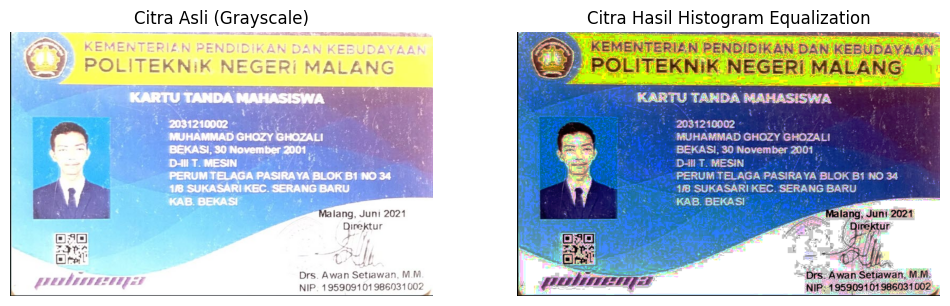

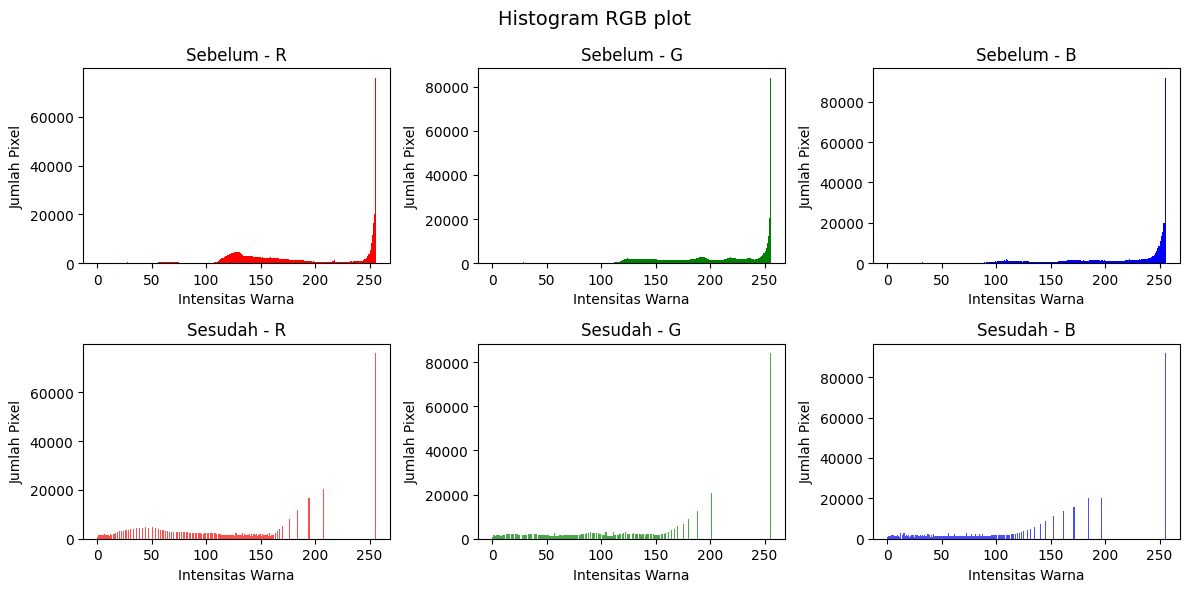

In [12]:
# Start / Input Image
img = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Hitung Frekuensi (histogram)
hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])


# Hitung Kumulatif Frekuensi
cdf = hist.cumsum()

# Normalisasi CDF (bagi dengan jumlah pixel dan skala ke 0-255)
cdf_normalized = cdf * 255 / cdf[-1]

# Implementasi rumus transformasi equalization
img_eq = np.interp(img.flatten(), bins[:-1], cdf_normalized)
img_eq = img_eq.reshape(img.shape).astype('uint8')

# Visualisasi
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Citra Asli (Grayscale)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Citra Hasil Histogram Equalization")
plt.axis("off")
plt.show()

# Pisah channel RGB
R, G, B = cv.split(img)

# Equalize per channel
R_eq = cv.equalizeHist(R)
G_eq = cv.equalizeHist(G)
B_eq = cv.equalizeHist(B)

# Gabungkan kembali
channels_orig = [R, G, B]
channels_eq = [R_eq, G_eq, B_eq]

plt.figure(figsize=(12,6))
plt.suptitle("Histogram RGB plot", fontsize=14)

for i, col in enumerate(colors):
    # Sebelum equalization (baris atas)
    plt.subplot(2,3,i+1)
    plt.hist(channels_orig[i].ravel(), bins=256, range=(0,256), color=col)
    plt.title(f"Sebelum - {col.upper()}")
    plt.xlabel("Intensitas Warna")
    plt.ylabel("Jumlah Pixel")

    # Sesudah equalization (baris bawah)
    plt.subplot(2,3,i+4)
    plt.hist(channels_eq[i].ravel(), bins=256, range=(0,256), color=col, alpha=0.7)
    plt.title(f"Sesudah - {col.upper()}")
    plt.xlabel("Intensitas Warna")
    plt.ylabel("Jumlah Pixel")

plt.tight_layout()
plt.show()

#### D-3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image
awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman
modul ini! (Gunakan gambar lena.jpg)

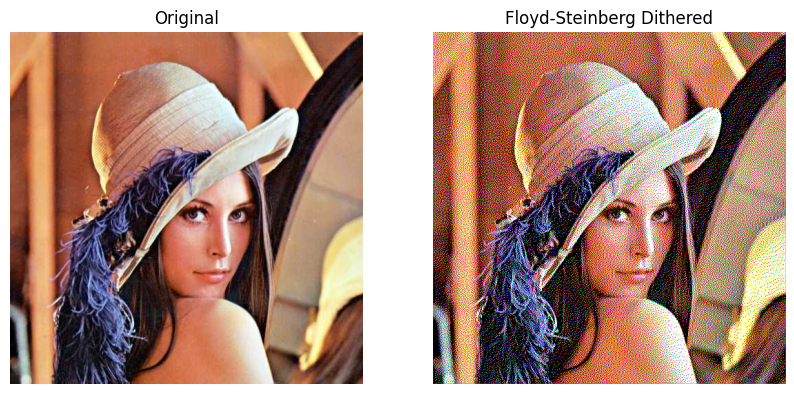

In [8]:
def threshold(value):
    """Batas biner sesuai flowchart"""
    if value > 255:
        return 255
    elif value < 0:
        return 0
    else:
        return 0 if value < 128 else 255

def floyd_steinberg_color(image):
    # copy sebagai float untuk perhitungan error
    h, w, c = image.shape
    img = image.astype(np.float32).copy()

    for y in range(h-1):
        for x in range(1, w-1):
            old_pixel = img[y, x].copy()  # [B,G,R]
            new_pixel = np.array([threshold(v) for v in old_pixel])
            img[y, x] = new_pixel

            error = old_pixel - new_pixel

            # Sebar error ke tetangga
            img[y, x+1]     += error * 7/16
            img[y+1, x-1]   += error * 3/16
            img[y+1, x]     += error * 5/16
            img[y+1, x+1]   += error * 1/16

    return np.clip(img, 0, 255).astype(np.uint8)

# Load lena.jpg (warna)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Terapkan Floyd-Steinberg Dithering (warna)
dithered = floyd_steinberg_color(img)

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Floyd-Steinberg Dithered")
plt.imshow(dithered)
plt.axis("off")

plt.show()

2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram
equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil
histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga
menampilkan gambar di bawah ini!

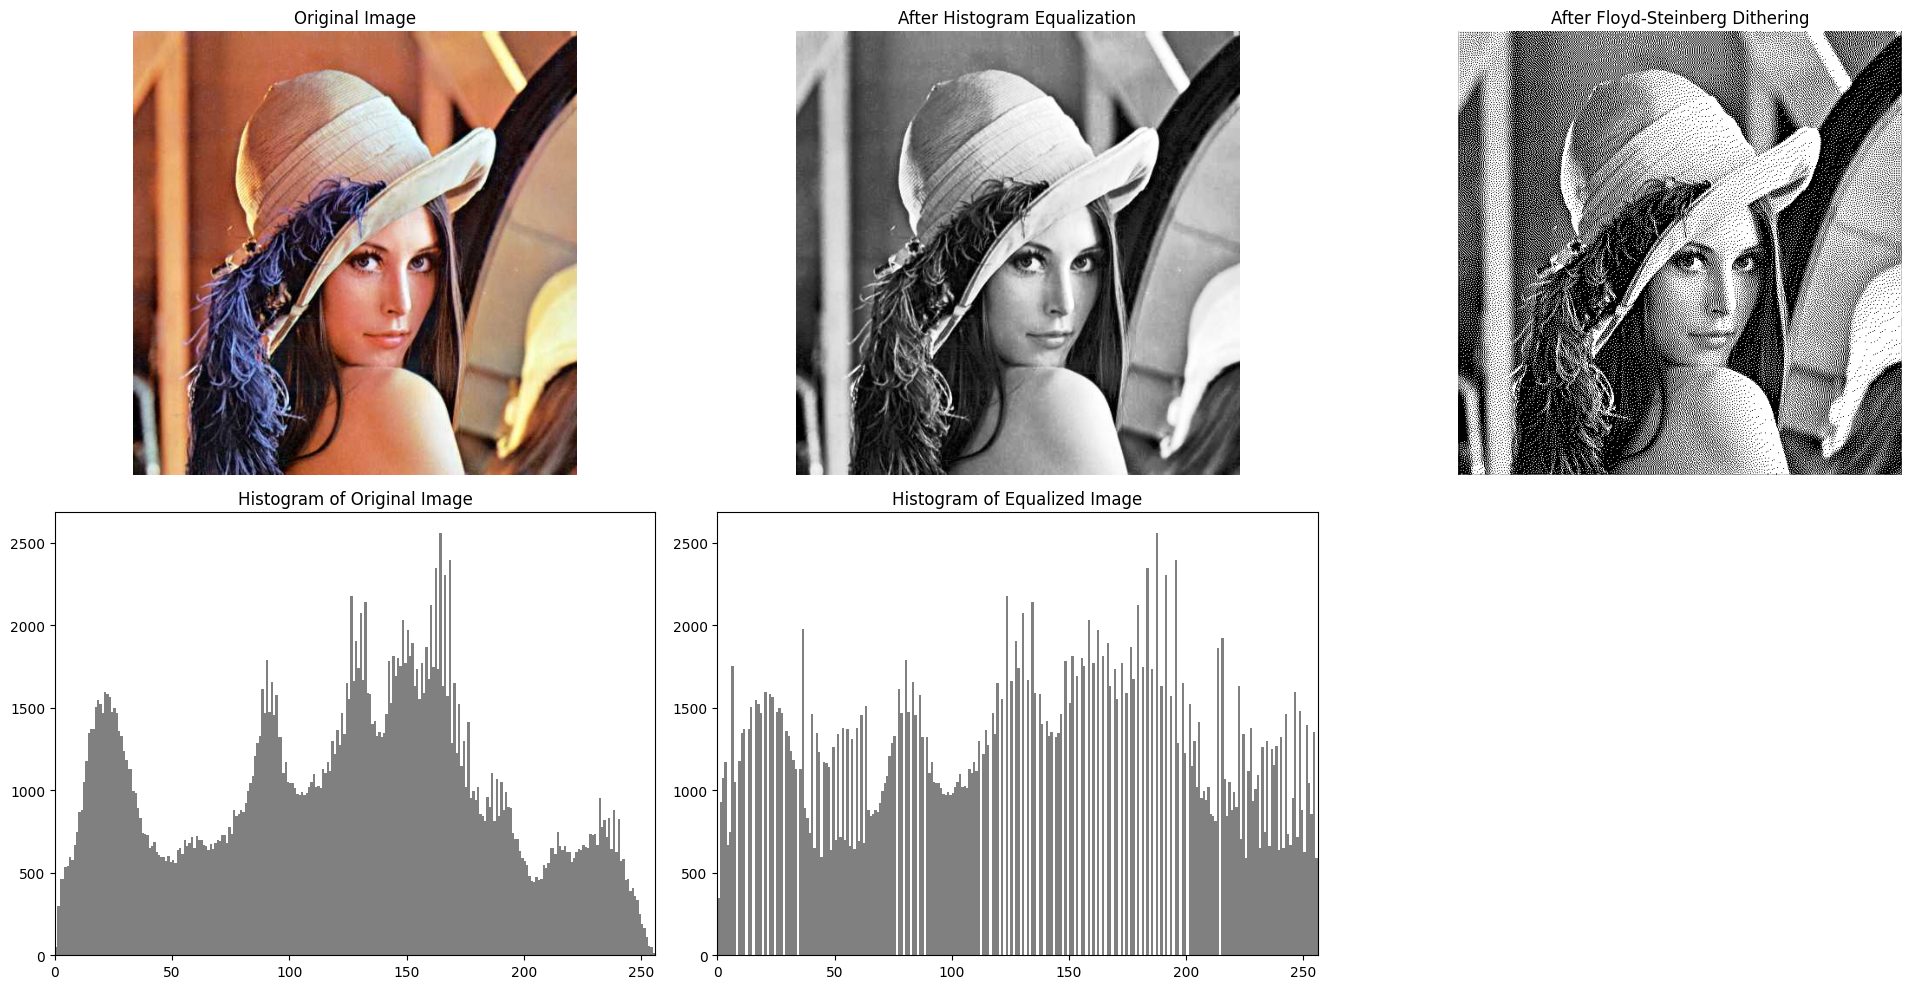

In [15]:
# Load the image
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img_ori = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert the image to grayscale
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply histogram equalization
equalized_img = cv.equalizeHist(gray_img)

# Floyd-Steinberg dithering matrix
fs_matrix = np.array([[0, 0, 7],
                      [3, 5, 1]]) / 16

# Normalize the equalized image to have pixel values between 0 and 1
img_normalized = equalized_img.astype(np.float32) / 255.0

# Get the dimensions of the image
rows, cols = img_normalized.shape

# Create a copy of the image to apply the dithering
dithered_img = np.copy(img_normalized)

# Apply Floyd-Steinberg dithering
for y in range(rows - 1):
    for x in range(1, cols - 1):
        old_pixel = dithered_img[y, x]
        new_pixel = np.round(old_pixel)  # Quantize to either 0 or 1
        dithered_img[y, x] = new_pixel
        error = old_pixel - new_pixel

        # Distribute the error to neighboring pixels
        dithered_img[y, x + 1] += error * 7 / 16
        dithered_img[y + 1, x - 1] += error * 3 / 16
        dithered_img[y + 1, x] += error * 5 / 16
        dithered_img[y + 1, x + 1] += error * 1 / 16

# Convert dithered image back to 0-255 range for display
dithered_img = (dithered_img * 255).astype(np.uint8)

# Plot original, equalized, dithered images and their histograms
plt.figure(figsize=(20, 10))

# Original Image and Histogram
plt.subplot(2, 3, 1)
plt.imshow(img_ori)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(gray_img.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Original Image')
plt.xlim([0, 256])

# Equalized Image and Histogram
plt.subplot(2, 3, 2)
plt.imshow(equalized_img, cmap='gray')
plt.title('After Histogram Equalization')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.hist(equalized_img.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Equalized Image')
plt.xlim([0, 256])

# Dithered Image and Histogram
plt.subplot(2, 3, 3)
plt.imshow(dithered_img, cmap='gray')
plt.title('After Floyd-Steinberg Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()
